In [1]:
import os
import json
import random
from pathlib import Path
import numpy as np
from einops import rearrange
import shutil
from collections import defaultdict

import torch
from tqdm import tqdm
import torchaudio
import wave

import matplotlib.pyplot as plt
import librosa
import librosa.display

from stable_audio_tools.models.factory import create_model_from_config
from stable_audio_tools.models.utils import load_ckpt_state_dict
from stable_audio_tools.inference.generation import generate_diffusion_cond

# os.add_dll_directory(r'C:\ffmpeg_shared\bin')

# Generation

In [8]:
def generate_samples(model, model_name, samples, class_mappings: str = "class_mapping.json", cfg:float  = 6.0, audio_length:int = 12, sample_rate = 44100, steps = 100, hybrid = True, device = "cuda"):

    with open(class_mappings, "r", encoding="utf-8") as file:
        class_mappings = json.load(file)

    sample_size = int(audio_length * sample_rate)

    base_dir = Path(f"generations/{model_name}")
    base_dir.mkdir(parents=True, exist_ok=True)

    for class_name, mapping in class_mappings.items():
        target_id = mapping["id"]
        target_str = mapping["name"]

        class_dir = base_dir / class_name
        class_dir.mkdir(exist_ok=True)

        if hybrid:
            prompt = f"A field recording of a {target_str} singing in nature, stereo audio."
        else:
            prompt = f"A field recording of a bird singing in nature, stereo audio."

        conditioning = [{
        "prompt": prompt,
        "seconds_start": 0,
        "seconds_total": audio_length,
        "species_id": target_id
        }]
        
        for sample_idx in tqdm(range(samples), desc=f"Generating {class_name} (ID: {target_id})", unit="sample"):
            dynamic_seed = random.randint(0, 2147483647)
            with torch.no_grad():
                output = generate_diffusion_cond(
                    model,
                    steps=steps,
                    cfg_scale=cfg,
                    conditioning=conditioning,
                    sample_size=sample_size,
                    sigma_min=0.3,
                    sigma_max=500,
                    sampler_type="dpmpp-3m-sde",
                    device=device,
                    seed=dynamic_seed
                )

            file_out = class_dir / f"{class_name}_{sample_idx + 1}.wav"
            output = output.to(torch.float32).div(torch.max(torch.abs(output))).clamp(-1, 1).cpu()
            output = rearrange(output, "b d n -> d (b n)")
            torchaudio.save(file_out, output, sample_rate)
    print(f"Generations saved to generations/{model_name}")       

In [9]:
CONFIG_PATH = "checkpoints/model_config_no_prompt.json"
CKPT_PATH = "runs/no_pompt/epoch=38-step=10000.ckpt"

with open(CONFIG_PATH, "r") as f:
    model_config = json.load(f)

sample_rate = model_config["sample_rate"]
model = create_model_from_config(model_config)

In [ ]:
raw_state_dict = load_ckpt_state_dict(CKPT_PATH)

clean_state_dict = {}
for key, value in raw_state_dict.items():
    if key.startswith('diffusion_ema.ema_model.'):
        new_key = key.replace('diffusion_ema.ema_model.', 'model.')
        clean_state_dict[new_key] = value
        
    
    elif key.startswith('diffusion.'):
        new_key = key.replace('diffusion.', '')
        
        if new_key not in clean_state_dict:
            clean_state_dict[new_key] = value

model.load_state_dict(clean_state_dict, strict=False)

device = "cuda" if torch.cuda.is_available() else "cpu"
# model = model.to(device, dtype=torch.float16)
model = model.to(device, dtype=torch.bfloat16)
model.eval()
print(f"Model successfully loaded on {device} in bfloat16!")

In [ ]:
cfg_range= [3.0, 6.0, 9.0]

for cfg_val in cfg_range:
    generate_samples(model, f"no_prompt_10000_cfg{int(cfg_val)}", 30, "class_mapping_general_cross.json", cfg=cfg_val, hybrid=False)


# Evaluation

In [2]:
from frechet_audio_distance import FrechetAudioDistance

def flat_folder_for_fad(nested_folder, out_name=None):
    nested = Path(nested_folder)
    base_folder = Path("flats")

    if out_name is None:
        out_name = f"{nested.name}_flat"

    flat = base_folder / out_name

    if flat.exists() and any(flat.iterdir()):
        print(f"Directory '{flat}' already exists and contains files. Skipping flattening.")
        return flat

    flat.mkdir(parents=True, exist_ok=True)
    gen_wavs = list(nested.rglob("*.wav"))

    for wav_file in tqdm(gen_wavs, desc="Flattening folders"):
        if wav_file.stat().st_size == 0:
            print(f"Empty file: {wav_file.name}")
            continue
            
        try:
            info = torchaudio.info(str(wav_file))
            duration = info.num_frames / info.sample_rate
            
            if duration < 0.5:
                print(f"File too short ({duration:.2f}s): {wav_file.name}")
                continue
        except Exception as e:
            print(f"Failed to read {wav_file.name}. Error: {e}")
            continue

        dest_file = flat / wav_file.name
        counter = 1
        while dest_file.exists():
            dest_file = flat / f"{wav_file.stem}_{counter}{wav_file.suffix}"
            counter += 1

        try:
            shutil.copy(wav_file, dest_file)
        except Exception as e:
            print(f"Failed to copy {wav_file.name}: {e}")

    print(f"All files successfully copied to: {flat}")
    return flat

def evaluate_quality(real_audio_path, generated_audio_path, real_out_name=None, gen_out_name=None):
    
    real_audio_dir = flat_folder_for_fad(real_audio_path, real_out_name)
    generated_audio_dir = flat_folder_for_fad(generated_audio_path, gen_out_name)

    _original_load = torch.load
    def _patched_load(*args, **kwargs):
        kwargs['weights_only'] = False
        return _original_load(*args, **kwargs)

    torch.load = _patched_load

    try:
        frechet = FrechetAudioDistance(
            model_name="pann",
            sample_rate=16000,
            use_pca=False,
            use_activation=False,
            verbose=True
        )
    except Exception as e:
        print(e)
        return None
    finally:
        torch.load = _original_load
        print("PyTorch security settings restored.")

    try:
        print("\nCalculating FAD score")
        fad_score = frechet.score(real_audio_dir, generated_audio_dir)
        print(f"\nFINAL PANNs FAD SCORE: {fad_score:.4f}")
        return fad_score
    except Exception as e:
        print(f"Error during FAD calculation: {e}")
        return None

In [13]:
real_audio_dir = "data_preprocessed_general"  
generated_audio_dir = "generations/no_prompt_10000_cfg9"
evaluate_quality(real_audio_dir, generated_audio_dir)

Directory 'flats\data_preprocessed_general_flat' already exists and contains files. Skipping flattening.


Flattening folders: 100%|██████████| 630/630 [00:05<00:00, 113.72it/s]


All files successfully copied to: flats\no_prompt_10000_cfg9_flat
[Frechet Audio Distance] Using device: cuda
PyTorch security settings restored.

Calculating FAD score


  0%|          | 0/4190 [00:00<?, ?it/s]

[Frechet Audio Distance] Loading audio from flats\data_preprocessed_general_flat...


...

 97%|█████████▋| 610/630 [00:06<00:00, 94.72it/s]

[Frechet Audio Distance] Embedding shape: torch.Size([2048])
[Frechet Audio Distance] Embedding shape: torch.Size([2048])
[Frechet Audio Distance] Embedding shape: torch.Size([2048])
[Frechet Audio Distance] Embedding shape: torch.Size([2048])
[Frechet Audio Distance] Embedding shape: torch.Size([2048])
[Frechet Audio Distance] Embedding shape: torch.Size([2048])
[Frechet Audio Distance] Embedding shape: torch.Size([2048])
[Frechet Audio Distance] Embedding shape: torch.Size([2048])
[Frechet Audio Distance] Embedding shape: torch.Size([2048])
[Frechet Audio Distance] Embedding shape: torch.Size([2048])
[Frechet Audio Distance] Embedding shape: torch.Size([2048])
[Frechet Audio Distance] Embedding shape: torch.Size([2048])
[Frechet Audio Distance] Embedding shape: torch.Size([2048])
[Frechet Audio Distance] Embedding shape: torch.Size([2048])
[Frechet Audio Distance] Embedding shape: torch.Size([2048])
[Frechet Audio Distance] Embedding shape: torch.Size([2048])
[Frechet Audio Distance]

100%|██████████| 630/630 [00:06<00:00, 94.85it/s] 


[Frechet Audio Distance] Embedding shape: torch.Size([2048])
[Frechet Audio Distance] Embedding shape: torch.Size([2048])
[Frechet Audio Distance] Embedding shape: torch.Size([2048])
[Frechet Audio Distance] Embedding shape: torch.Size([2048])
[Frechet Audio Distance] Embedding shape: torch.Size([2048])
[Frechet Audio Distance] Embedding shape: torch.Size([2048])
[Frechet Audio Distance] Embedding shape: torch.Size([2048])
[Frechet Audio Distance] Embedding shape: torch.Size([2048])

FINAL PANNs FAD SCORE: 0.0006


0.000595687581507881

In [2]:
from birdnetlib import Recording
from birdnetlib.analyzer import Analyzer

EBIRD_TO_BIRDNET = {
    "amepip": "american pipit",
    "amerob": "american robin",
    "brebla": "brewer's blackbird",
    "casfin": "cassin's finch",
    "clanut": "clark's nutcracker",
    "daejun": "dark-eyed junco",
    "dusfly": "dusky flycatcher",
    "foxspa": "fox sparrow",
    "herthr": "hermit thrush",
    "mallar3": "mallard",
    "moublu": "mountain bluebird",
    "mouchi": "mountain chickadee",
    "norfli": "northern flicker",
    "orcwar": "orange-crowned warbler",
    "rocwre": "rock wren",
    "sposan": "spotted sandpiper",
    "warvir": "warbling vireo",
    "whcspa": "white-crowned sparrow",
    "yelwar": "yellow warbler",
    "yerwar": "yellow-rumped warbler", # <- main species code, subspecies -> MYWA
    "gcrfin": "gray-crowned rosy-finch"
}

C:\Users\Leonard Leber\master\Stable-Audio-Open-Birdcall-Generation\venv_birdnet\lib\site-packages\pydub\utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)


In [3]:
def evaluate_species_accuracy(generated_audio_dir):
    generated_audio_path = Path(generated_audio_dir)
    analyzer = Analyzer()
    
    total_files = 0
    correct_predictions = 0
    
    class_stats = defaultdict(lambda: {"total": 0, "correct": 0})
    
    for class_folder in generated_audio_path.iterdir():
        if not class_folder.is_dir():
            continue
            
        
        folder_code = class_folder.name.lower()
        target_bird_name = EBIRD_TO_BIRDNET.get(folder_code, folder_code)
        
        for audio_file in class_folder.glob("*.wav"):
            total_files += 1
            class_stats[target_bird_name]["total"] += 1
            
            try:
                recording = Recording(
                    analyzer, 
                    str(audio_file), 
                    min_conf=0.1 
                )
                recording.analyze()
                
                predictions = [d['common_name'].lower() for d in recording.detections]
                
                is_correct = any(target_bird_name in pred for pred in predictions)
                
                if is_correct:
                    correct_predictions += 1
                    class_stats[target_bird_name]["correct"] += 1
                else:
                    print(f"[MISS] {audio_file.name} - Predicted: {predictions[:3]}")
                    
            except Exception as e:
                print(f"Error processing {audio_file.name}: {e}")

    print("\n--- BirdNET Accuracy Results ---")
    for bird, stats in class_stats.items():
        acc = (stats["correct"] / stats["total"]) * 100 if stats["total"] > 0 else 0
        print(f"{bird.title()}: {acc:.1f}% ({stats['correct']}/{stats['total']})")
        
    overall_acc = (correct_predictions / total_files) * 100 if total_files > 0 else 0
    print(f"\nOVERALL ACCURACY: {overall_acc:.2f}%")

In [16]:
generated_audio_folders = "data_preprocessed_general"
evaluate_species_accuracy(generated_audio_folders)

Labels loaded.
load model True
Model loaded.
Labels loaded.
load_species_list_model
Meta model loaded.
read_audio_data
read_audio_data: complete, read  11 chunks.
analyze_recording XC111040.wav
read_audio_data
read_audio_data: complete, read  11 chunks.
analyze_recording XC111041.wav
read_audio_data
read_audio_data: complete, read  9 chunks.
analyze_recording XC111042.wav
read_audio_data
read_audio_data: complete, read  13 chunks.
analyze_recording XC111043.wav
read_audio_data
read_audio_data: complete, read  7 chunks.
analyze_recording XC113721.wav
read_audio_data
read_audio_data: complete, read  7 chunks.
analyze_recording XC113724.wav
read_audio_data
read_audio_data: complete, read  11 chunks.
analyze_recording XC135087.wav
read_audio_data
read_audio_data: complete, read  3 chunks.
analyze_recording XC141773.wav
read_audio_data
read_audio_data: complete, read  4 chunks.
analyze_recording XC144540.wav
read_audio_data
read_audio_data: complete, read  3 chunks.
analyze_recording XC1512

In [2]:
def plot_spectrogram(ax, audio_path, title, target_duration=11.0, vmin=-80, vmax=0):
    try:
        y, sr = librosa.load(audio_path, sr=None)
    
        if target_duration is not None:
            target_samples = int(target_duration * sr)
            y = librosa.util.fix_length(data=y, size=target_samples)
        
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
        S_dB = librosa.power_to_db(S, ref=1.0)
        
        img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, 
                                       fmax=8000, ax=ax, cmap='magma', 
                                       vmin=vmin, vmax=vmax)
        ax.set_title(title)
        return img
    except Exception as e:
        print(f"Could not load {audio_path}: {e}")
        return None
    
def show_spectrogram(class_id, nr_samples, real_audio_dir, generated_audio_dir, class_mappings, save_plot=False):
    with open(class_mappings, "r", encoding="utf-8") as file:
        class_mappings = json.load(file)
    class_name = next((key for key, val in class_mappings.items() if val["id"] == class_id), None)
    class_name = Path(class_name)

    real_files = list((real_audio_dir / class_name).rglob("*.wav"))
    gen_files = list((generated_audio_dir / class_name).rglob("*.wav"))
    
    selected_real = random.sample(real_files, min(nr_samples, len(real_files)))
    selected_gen = random.sample(gen_files, min(nr_samples, len(gen_files)))

    fig, axes = plt.subplots(nrows=nr_samples, ncols=2, figsize=(15, 4 * nr_samples), layout="constrained")

    if nr_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    img = None
    for i in range(nr_samples):
        plot_spectrogram(axes[i, 0], selected_real[i], f"REAL: {class_name}")
        img = plot_spectrogram(axes[i, 1], selected_gen[i], f"GENERATED: {selected_gen[i].name}")
        
    if img is not None:
        fig.colorbar(img, ax=axes, format='%+2.0f dB', shrink=0.8, aspect=40, pad=0.02)
    if save_plot:
        
        gen_dir_name = generated_audio_dir.name 
        save_dir = Path("spectrograms") / gen_dir_name 
        save_dir.mkdir(parents=True, exist_ok=True)
        save_path = save_dir / f"{class_name}_comparison.png"
        
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    
        plt.close(fig)
    else:
        plt.show()

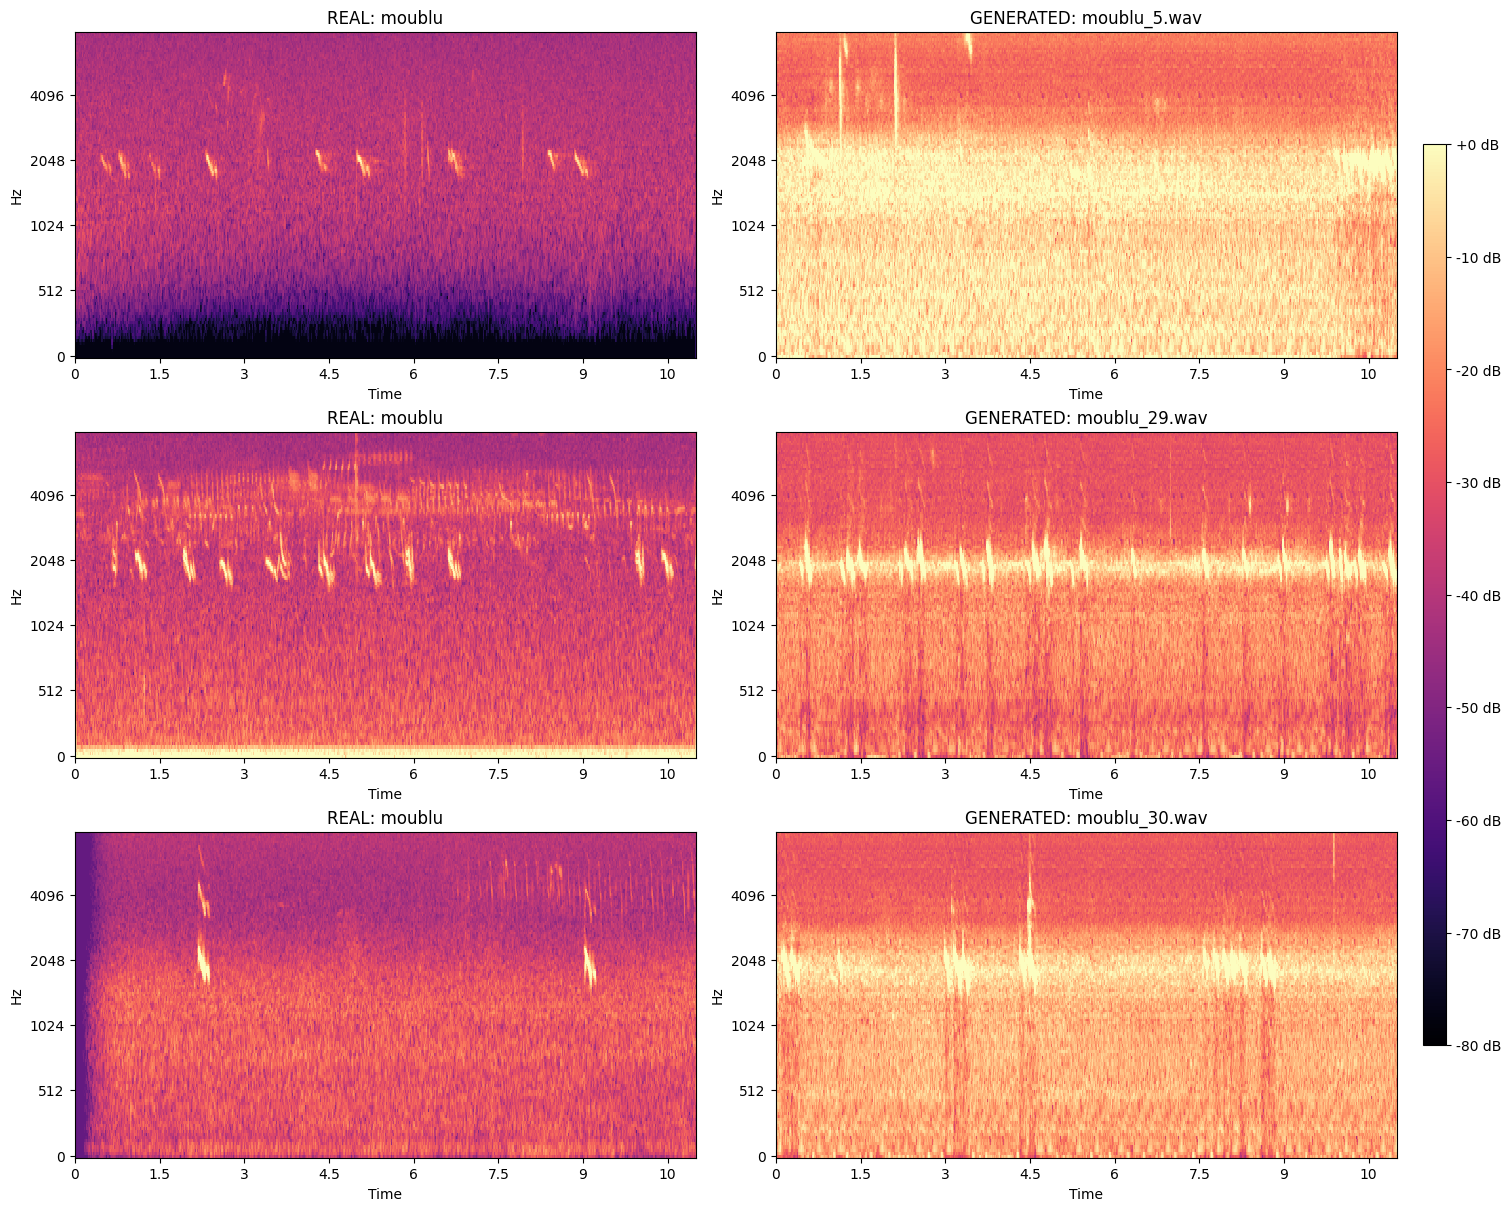

In [5]:
real_audio_dir = "data_preprocessed_general"  
generated_audio_dir = "generations/hybrid_10000_cfg9"
show_spectrogram(9, 3, real_audio_dir, generated_audio_dir, "class_mapping_runpod.json")

In [ ]:
real_audio_dir = Path("data_preprocessed_general")
base_generations_dir = Path("generations")
class_mapping_file = "class_mapping_runpod.json"

generation_folders = [d for d in base_generations_dir.iterdir() if d.is_dir()]

for gen_dir in generation_folders:
    for class_id in range(21):
        try:

            show_spectrogram(
                class_id=class_id, 
                nr_samples=5, 
                real_audio_dir=real_audio_dir, 
                generated_audio_dir=gen_dir, 
                class_mappings=class_mapping_file,
                save_plot=True 
            )
        except Exception as e:
            print(f"Skipped class_id {class_id} in {gen_dir.name}. Reason: {e}")
    print(f"Saved spectrograms for {gen_dir}")
print("\nAll folders processed successfully!")